### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P49 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

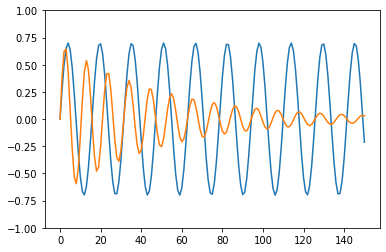

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 3

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

49

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.00028179073710622255   1.7646021842956543 sec      
199: 0.00018455890233620313   2.442934036254883 sec       
299: 0.00016053845423565254   3.126384973526001 sec       
399: 0.00014781809622283016   3.781250238418579 sec       
499: 0.0001400398660934845   4.473727703094482 sec        
599: 0.00013391327701214742   5.207243204116821 sec       
699: 0.00012755951863110336   5.911523342132568 sec       
799: 0.00012121378055443612   6.638868570327759 sec       
899: 0.00011507531865847528   7.244467258453369 sec       
999: 0.00010833600665652029   7.925370454788208 sec       
1099: 0.00010051168425861827   8.5836021900177 sec         
1199: 0.00029048201039632795   9.255753517150879 sec      
1299: 0.00010022936734398098   9.878582954406738 sec      
1399: 0.0001577393620614323   10.47083306312561 sec       
1499: 0.00010859432591484158   11.069042682647705 sec      
1599: 0.00010230722203170324   11.70737624168396 sec       
learning rate: 0.1
1699: 0.00045697

26499: 0.00021126913650199375   189.80866503715515 sec      
26599: 0.00020571844486185948   190.5248692035675 sec       
26699: 0.00020082692486422406   191.2242031097412 sec       
26799: 0.00019598262900331168   191.98311281204224 sec      
26899: 0.00019083741782484386   192.72566890716553 sec      
26999: 0.00018513713354698026   193.4502055644989 sec       
27099: 0.0001785183199485798   194.1624836921692 sec        
27199: 0.00016998001951175405   194.86540126800537 sec      
27299: 0.000154417854636204   195.56362986564636 sec        
27399: 0.00014837330424006615   196.26011180877686 sec      
27499: 0.00013834496476065468   196.96474361419678 sec      
27599: 0.00013341455051715966   197.68116879463196 sec      
27699: 0.00012911347001286138   198.4078507423401 sec       
27799: 0.0001250658405383381   199.1231656074524 sec        
27899: 0.00012133552794568573   199.86846160888672 sec      
27999: 0.0002490568608887276   200.5722086429596 sec        
28099: 0.000114279505132

52999: 0.0001114095185428782   378.26703000068665 sec       
53099: 0.000107899157340432   379.0030605792999 sec         
53199: 0.00010461174388121472   379.74391651153564 sec      
53299: 0.00010155941043389411   380.4730043411255 sec       
53399: 9.874379588430628e-05   381.2148823738098 sec        
53499: 0.00013760347827601965   381.933616399765 sec        
53599: 9.379540246150459e-05   382.6675474643707 sec        
53699: 9.159865452565938e-05   383.42483353614807 sec      
53799: 8.955148621152506e-05   384.16106128692627 sec      
53899: 8.762910668187332e-05   384.8912124633789 sec       
53999: 8.581344056668878e-05   385.68428325653076 sec      
54099: 8.537062138165745e-05   386.64271426200867 sec       
54199: 8.26761170773792e-05   387.4283814430237 sec        
54299: 8.109448382146117e-05   388.16879200935364 sec      
54399: 7.957950810693275e-05   388.92321515083313 sec      
54499: 8.245820617203118e-05   389.7568533420563 sec        
54599: 7.820716378638873e-05   

79499: 9.9619007971247e-05   577.6834588050842 sec         
79599: 9.35163672944724e-05   578.4193961620331 sec       
79699: 8.72454138955846e-05   579.1681027412415 sec       
79799: 8.061270051444953e-05   579.9383056163788 sec      
79899: 7.356977534630746e-05   580.6769299507141 sec      
79999: 6.674956339355175e-05   581.4229550361633 sec      
80099: 0.00017817698244036452   582.145026922226 sec       
80199: 0.0003255014963816516   582.8697395324707 sec       
80299: 0.00012701061124819658   583.6854226589203 sec      
learning rate: 0.05
80399: 0.02078336621095926   584.4440307617188 sec        
80499: 0.013399247711443504   585.2529306411743 sec      
80599: 0.00910534490925716   586.0297131538391 sec       
learning rate: 0.025
80699: 0.0019774281107161635   586.7796092033386 sec      
80799: 0.0014299221198690087   587.5227284431458 sec      
80899: 0.001043515121493479   588.2751891613007 sec       
80999: 0.0007562612717241578   589.0131986141205 sec      
81099: 0.0005

92899: 0.00010055936775535759   677.7145092487335 sec      
92999: 0.00010021463907241571   678.4362580776215 sec      
learning rate: 0.2
93099: 0.00041511215179337836   679.1862230300903 sec      
93199: 0.0002773393669588305   679.9439136981964 sec       
93299: 0.00023868022618951754   680.662846326828 sec       
93399: 0.00021637663904267417   681.417457818985 sec       
93499: 0.00020208297387439817   682.1416110992432 sec      
93599: 0.00023311510803869596   682.8755941390991 sec      
93699: 0.00020359346055701694   683.6067609786987 sec      
93799: 0.00017413965712323115   684.354252576828 sec       
93899: 0.0001554411907840794   685.0872714519501 sec       
93999: 0.0022413114442479004   685.8328680992126 sec       
94099: 0.00043193531301356216   686.5773012638092 sec      
94199: 0.00038362304493405705   687.3234362602234 sec      
learning rate: 0.1
94299: 0.00036902516966323153   688.0824630260468 sec      
94399: 0.00032116929198141886   688.8159122467041 sec      
94

...

247999: 0.00026647948301415777   1937.586580991745 sec       
248099: 0.00025895230552933107   1938.258819103241 sec       
248199: 0.0002524982465353869   1938.9483301639557 sec       
248299: 0.0002469305811956051   1939.6587226390839 sec       
248399: 0.000242120356915707   1940.3147971630096 sec        
248499: 0.00023799929481890935   1940.9776196479797 sec      
248599: 0.00023462845147721606   1941.7430310249329 sec      
248699: 0.00023183871217541627   1942.4348185062408 sec      
248799: 0.00022938259710903017   1943.1421678066254 sec      
248899: 0.00022713054162146816   1943.8155097961426 sec      
248999: 0.00022496776447330965   1944.4821047782898 sec      
249099: 0.00022277166454329054   1945.1548376083374 sec      
learning rate: 0.2
249199: 0.0004110033397692586   1945.85027551651 sec         
249299: 0.00025783958849008397   1946.5325646400452 sec      
249399: 0.00022175873591538846   1947.2184209823608 sec      
249499: 0.00021049392482158028   1947.8938591480255

273799: 0.00037307087497598026   2110.9979157447815 sec      
273899: 0.000407847156336896   2111.575515985489 sec         
273999: 0.00035743231364198844   2112.1639993190765 sec      
274099: 0.000349936458976079   2112.75528216362 sec          
274199: 0.00034256628243429106   2113.3578000068665 sec      
274299: 0.00033529711297447854   2113.9484736919403 sec      
274399: 0.0003281174347297875   2114.5162246227264 sec       
274499: 0.00032109723837776203   2115.1079404354095 sec      
274599: 0.00031375585399155936   2115.689134836197 sec       
274699: 0.00030683418481841504   2116.2674176692963 sec      
274799: 0.000300014326463638   2116.8779418468475 sec        
274899: 0.0002933014039915904   2117.4601879119873 sec       
274999: 0.0002931328760419681   2118.0467162132263 sec       
275099: 0.00027987781115952826   2118.6166677474976 sec      
275199: 0.0002735477939574626   2119.190591812134 sec        
275299: 0.0002673813722372884   2119.765142440796 sec        
275399: 

299399: 5.554386628958486e-05   2262.431726694107 sec        
299499: 5.9420135582792244e-05   2263.0371482372284 sec      
299599: 5.5179669428602423e-05   2263.6672024726868 sec      
299699: 6.052762594397236e-05   2264.273303747177 sec        
299799: 5.5460748202741124e-05   2264.907026529312 sec       
299899: 5.340513961562095e-05   2265.5028574466705 sec       
299999: 5.6175272454526866e-05   2266.09290266037 sec        
300099: 5.23262762523798e-05   2266.6895167827606 sec        
300199: 5.3897907702276294e-05   2267.2997555732727 sec      
300299: 5.0230674708225486e-05   2267.8787145614624 sec      
300399: 4.9706143575784e-05   2268.459719657898 sec          
300499: 4.82416479182831e-05   2269.0522198677063 sec        
300599: 4.75503776960591e-05   2269.6379544734955 sec        
300699: 0.00010346007272717867   2270.262850046158 sec       
300799: 4.922500048554417e-05   2270.8482575416565 sec       
300899: 4.768014436224822e-05   2271.44269490242 sec         
learning

325099: 0.00010594622115357106   2414.4033303260803 sec      
325199: 0.00012964785384161703   2414.9939272403717 sec      
325299: 9.483883553906846e-05   2415.5755467414856 sec       
325399: 0.00023694504886324693   2416.1572918891907 sec      
325499: 8.378434917429607e-05   2416.735486268997 sec        
325599: 0.00012055376940635002   2417.3133940696716 sec      
325699: 0.00022664794275965814   2417.894977092743 sec       
325799: 9.864517321508799e-05   2418.4708828926086 sec       
learning rate: 0.05
325899: 0.14086397137144752   2419.059269428253 sec         
325999: 0.13623439214764052   2419.659336566925 sec       
326099: 0.13270428113725846   2420.2385079860687 sec      
learning rate: 0.025
326199: 0.0014815254897897995   2420.8242526054382 sec      
326299: 0.0010934028390298426   2421.3977320194244 sec      
326399: 0.0010676017754115117   2421.972557783127 sec       
326499: 0.0010558918993507865   2422.5534467697144 sec      
326599: 0.001045851823927305   2423.1305

350599: 0.0004993368958966229   2565.0162608623505 sec      
350699: 0.00027461609820223675   2565.596718788147 sec       
350799: 0.00022976706623773302   2566.1887743473053 sec      
350899: 0.00019962465081363608   2566.7788741588593 sec      
350999: 0.00017637556081183628   2567.368546485901 sec       
351099: 0.00016407469283702137   2567.9690747261047 sec      
351199: 0.013594736847102815   2568.572125673294 sec         
351299: 0.0008018790849499952   2569.1641943454742 sec      
351399: 0.0006206967133148908   2569.7611486911774 sec      
learning rate: 0.1
351499: 0.009956820465284209   2570.3736419677734 sec       
351599: 0.005782937075523723   2570.9666242599487 sec       
351699: 0.0057527361875147585   2571.5409779548645 sec      
learning rate: 0.05
351799: 0.0006402738579053713   2572.1199605464935 sec      
351899: 0.00041270053789026906   2572.696747779846 sec       
351999: 0.0003472818340035367   2573.304979801178 sec        
352099: 0.00030957062776970016   2573.

In [ ]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

In [23]:
minLoss

Array(3.83932381e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

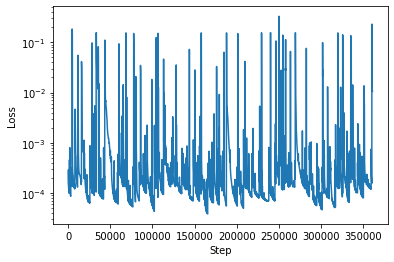

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

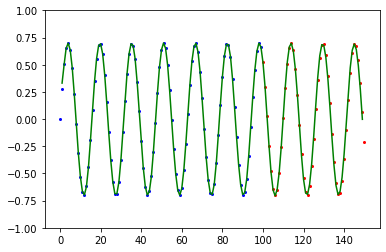

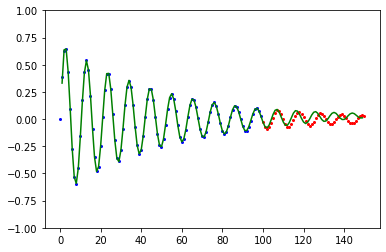

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

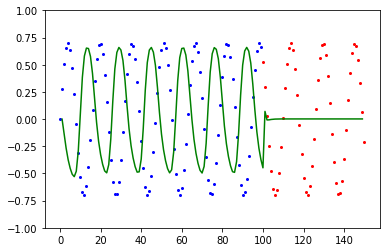

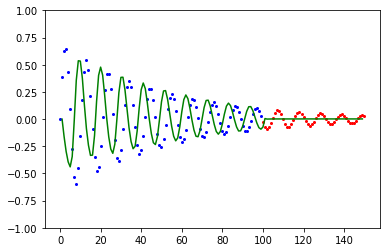

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[121700,
 Array(0.00013303, dtype=float64),
 Array(0.00106796, dtype=float64),
 [((Array([[ 1.20930413, -0.23888082,  3.67296325]], dtype=float64),
    Array([[  5.66109253,   4.80696556,  -3.79607829],
           [-17.0824474 ,   0.20742316,   4.32329529],
           [ -1.95909177,   2.86675897,   1.50350965]], dtype=float64),
    Array([ 2.54557693, -0.87353857, -1.59116192], dtype=float64)),
   (Array([[ 3.32653406,  0.15737925, -5.12436618]], dtype=float64),
    Array([[-0.03994484, -1.38440849,  1.01617649],
           [ 4.47451154,  2.42083384, -4.20251182],
           [-0.35956923,  0.23891287, -1.83261047]], dtype=float64),
    Array([-0.37623954, -1.35548569,  2.8039627 ], dtype=float64)),
   (Array([[-1.34078922, -0.29345419, -1.18302717]], dtype=float64),
    Array([[ 3.42651903,  2.28777489,  1.90567643],
           [10.14180146, -0.35454704,  1.26556543],
           [ 2.0874044 ,  0.57753271, -1.27259809]], dtype=float64),
    Array([-0.9883206 , -0.27457318, -0.2520208 ],

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

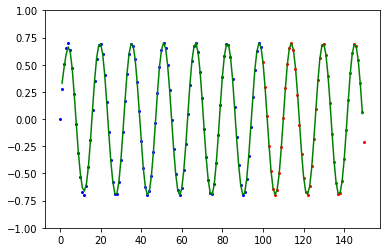

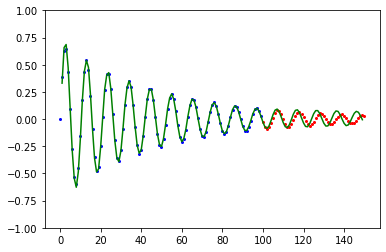

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [121700, Array(0.00013303, dtype=float64), Array(0.00106796, dtype=float64)]
3200 8.592130850616887e-05 0.12792326521193795


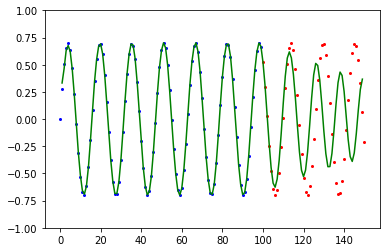

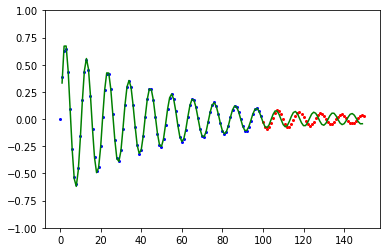

11300 0.00013090972417494407 0.16902863115919278


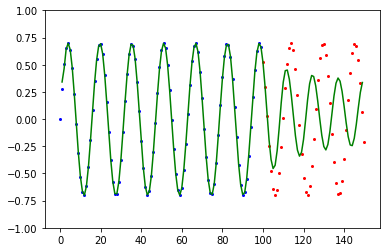

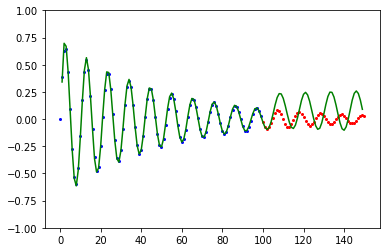

18800 0.0006016070205183373 0.13219683419949183


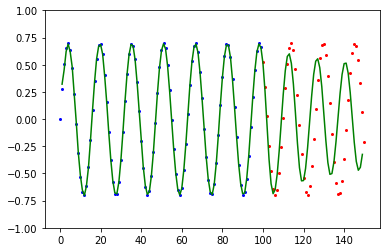

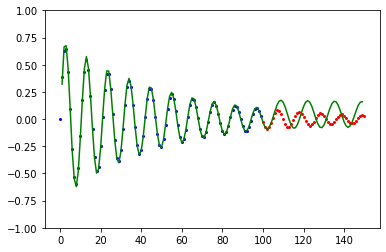

25900 6.322561148184421e-05 0.1498276184095039


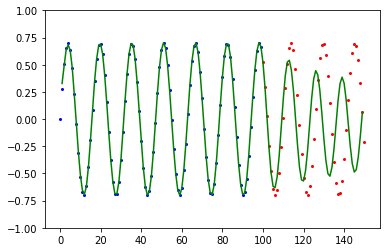

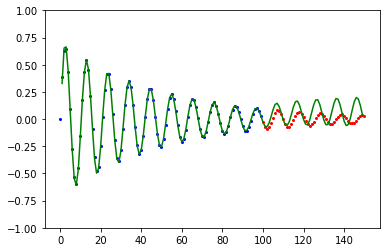

31100 8.95769271642446e-05 0.12673665341648715


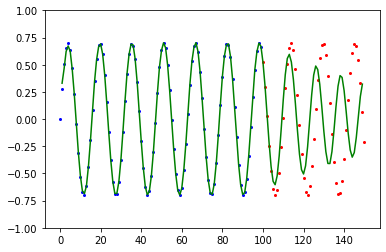

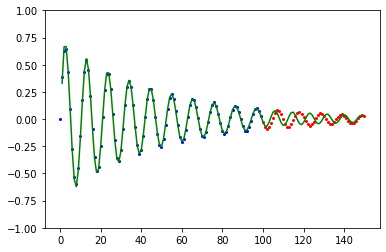

42100 7.685528542576875e-05 0.07671471788855015


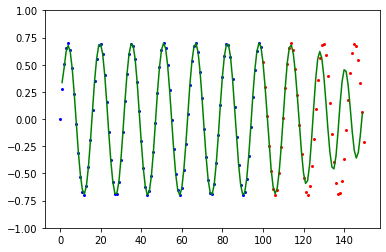

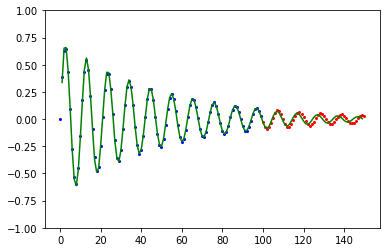

59400 6.0356529767435306e-05 0.17810352403056492


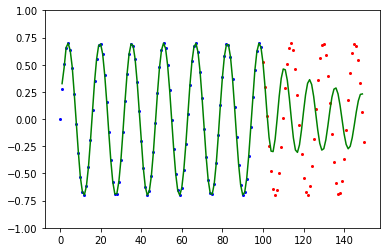

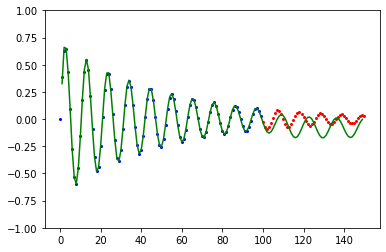

67600 0.00013447010716717333 0.15849046399435868


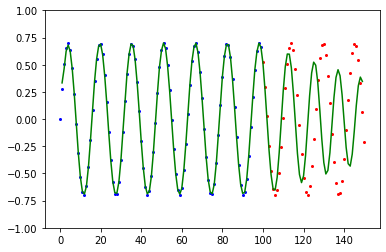

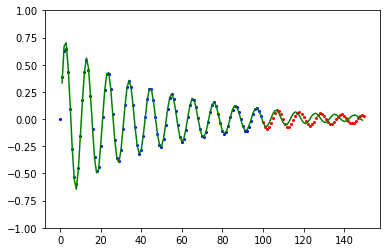

76800 5.2908568729544364e-05 0.12020188063859082


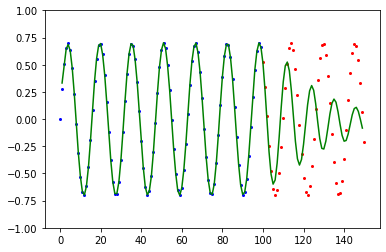

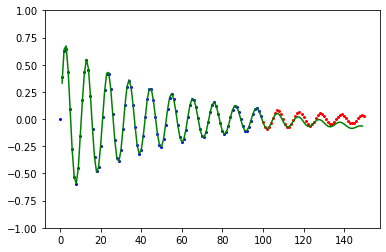

84500 6.942557381618305e-05 0.15273128659872576


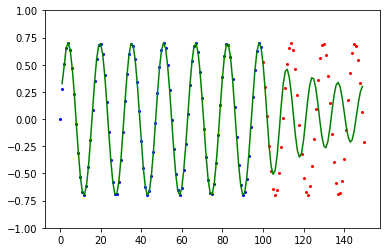

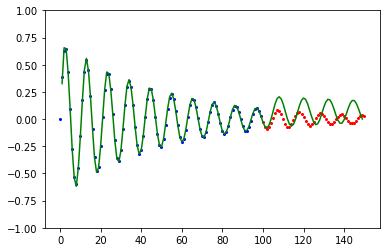

93000 0.00010021463907241571 0.187914386925114


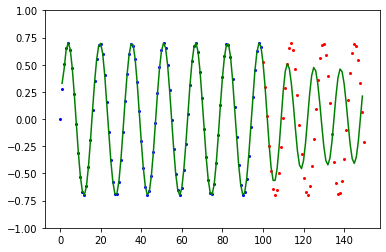

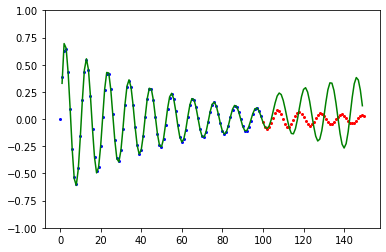

102400 4.323788985972677e-05 0.0691638011539535


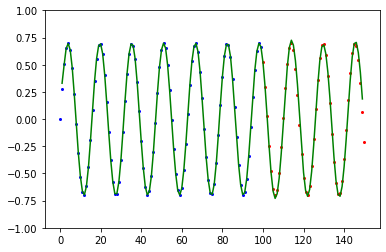

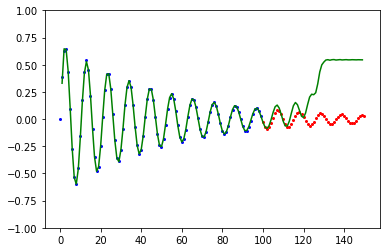

105600 0.00016735247665489162 0.03939615241039989


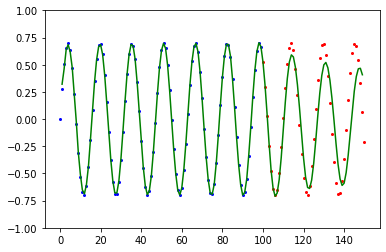

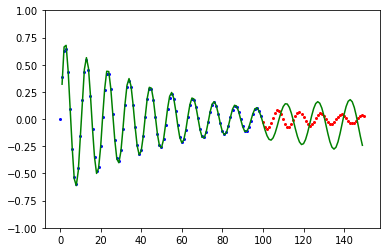

107400 0.012430605375869801 0.18816778640211862


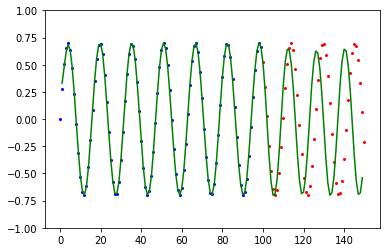

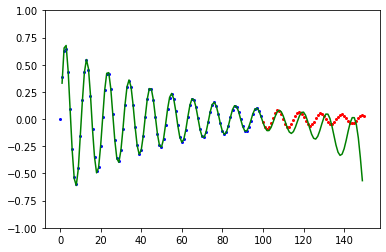

113300 9.369390009348726e-05 0.1555820177397708


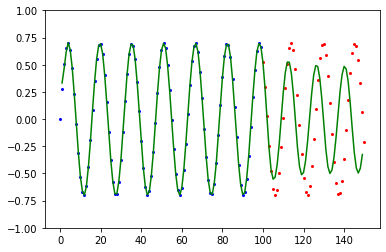

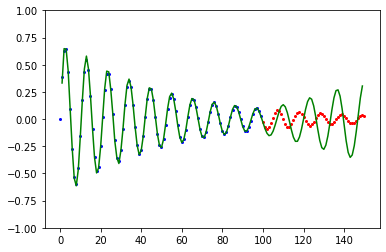

121700 0.00013302857918115005 0.0010679640298742988


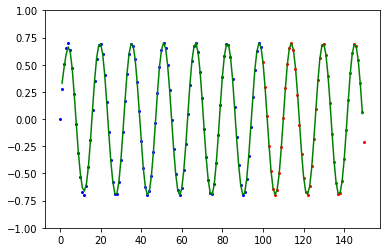

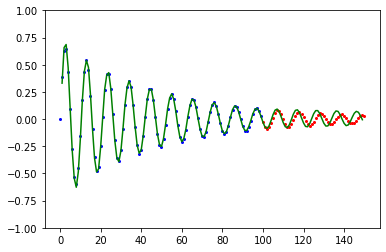

127200 0.00013452545480580107 0.17122038039858928


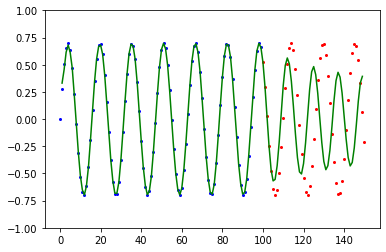

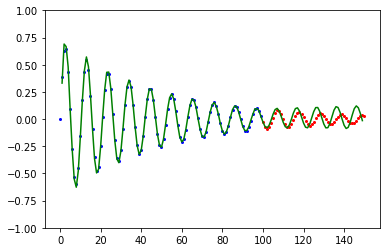

135000 9.739205551083255e-05 0.14663651820023132


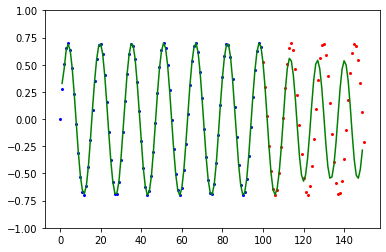

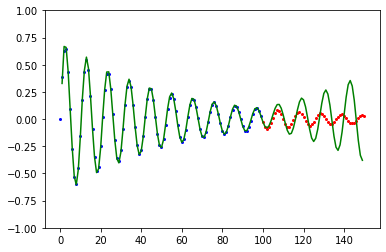

141000 0.00011768453455877609 0.18936508682908076


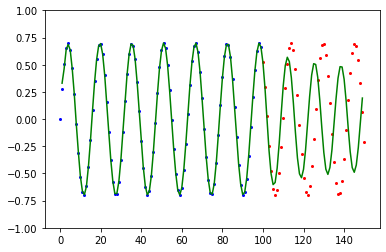

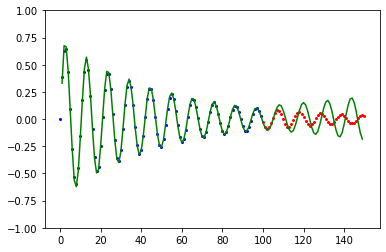

148600 7.00190823224268e-05 0.1457265585102883


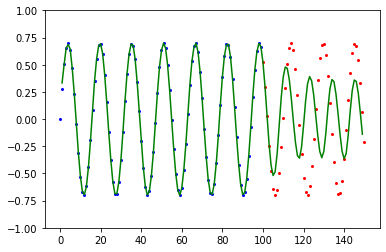

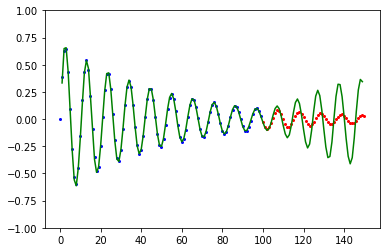

155900 6.860520554815559e-05 0.008859610210538304


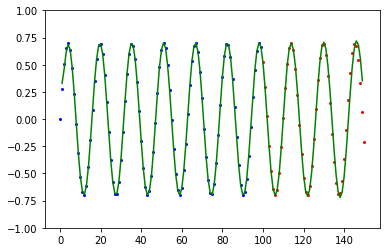

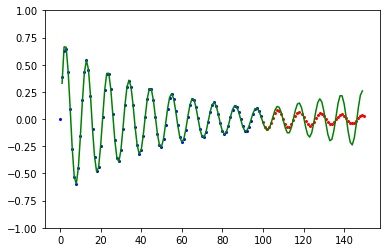

165700 3.839323806186114e-05 0.0014096396711136211


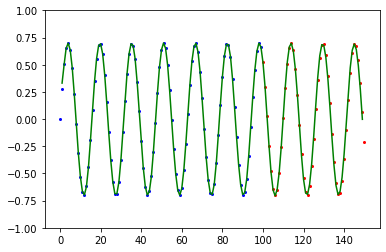

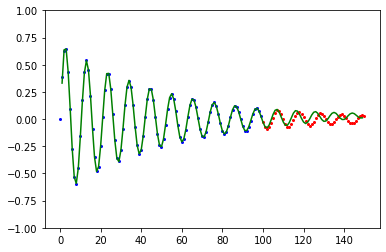

172500 6.392037729806447e-05 0.22730282844506777


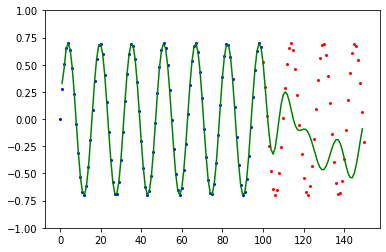

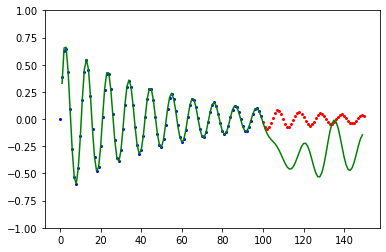

179200 5.773841434439313e-05 0.016275094696101933


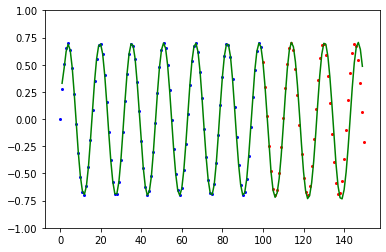

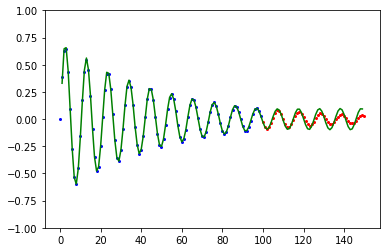

183700 0.0001122891589874384 0.08704793494117703


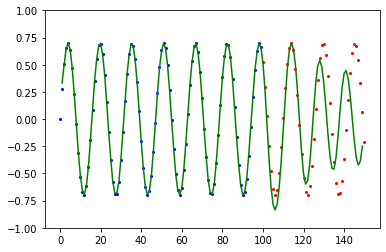

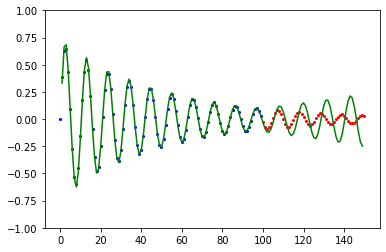

200800 5.483817596943713e-05 0.013819812374684732


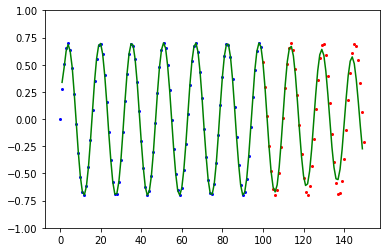

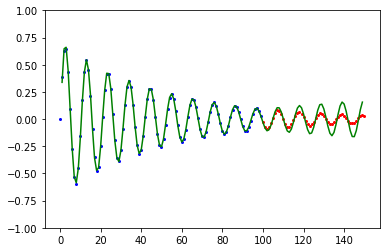

208200 4.961350256740089e-05 0.25574688834978526


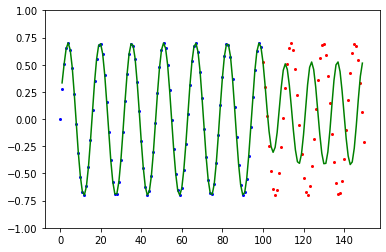

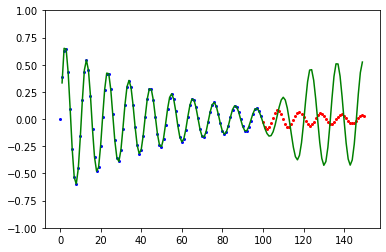

211800 0.00012192836902619948 0.1515153151293065


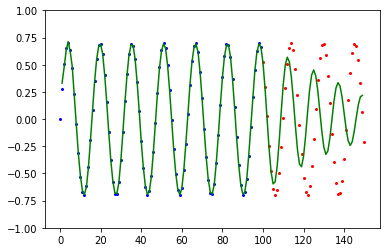

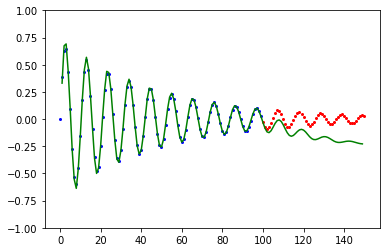

218000 8.158452726169205e-05 0.13288292787387637


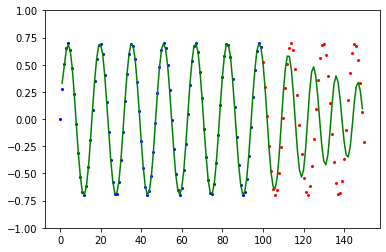

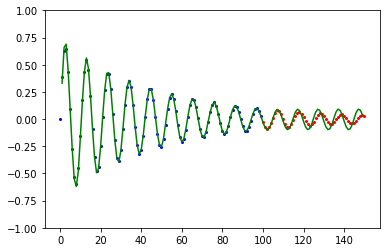

226700 7.988371387594368e-05 0.22759121844381144


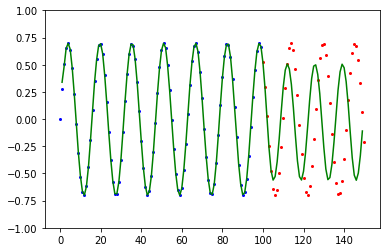

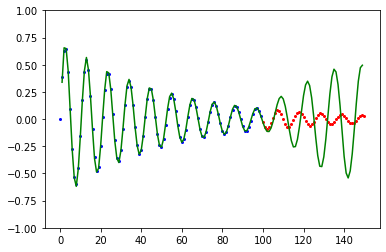

238200 6.984623745270436e-05 0.1687374719304254


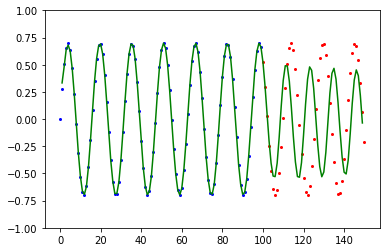

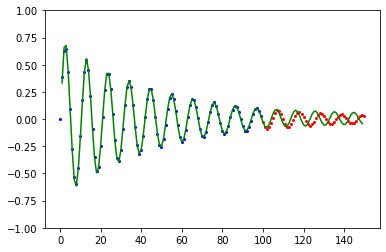

245500 6.954592029193113e-05 0.29786382878088935


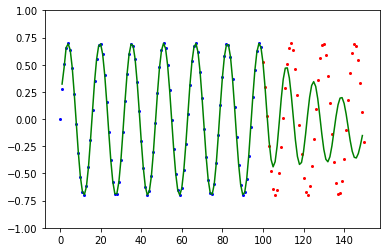

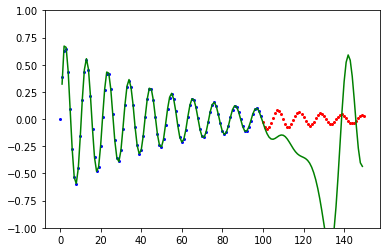

249100 0.00022277166454329054 0.07133527789898218


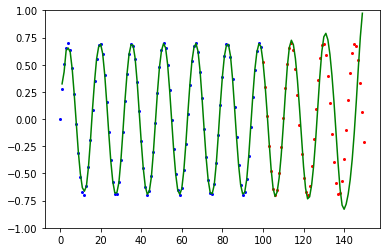

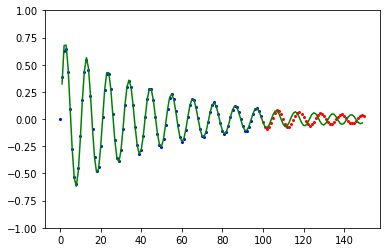

256700 0.00011712307752000948 0.1680770123094337


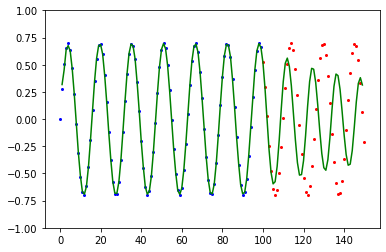

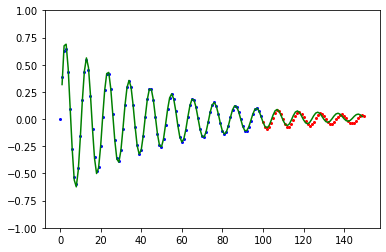

263200 0.00013410498544636512 0.21461598030689047


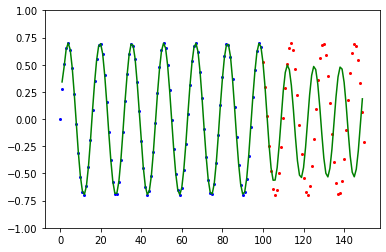

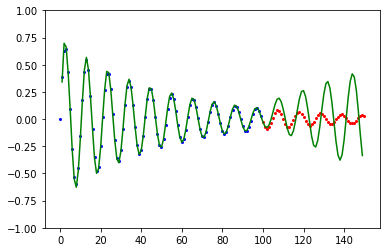

269000 0.0001312532406232617 0.12985325888895866


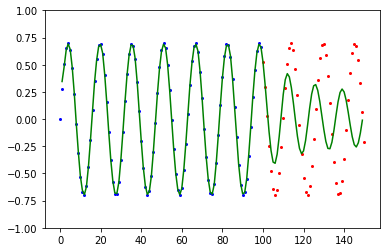

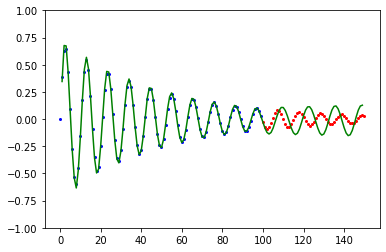

280800 0.0001227492883250879 0.17542841499391043


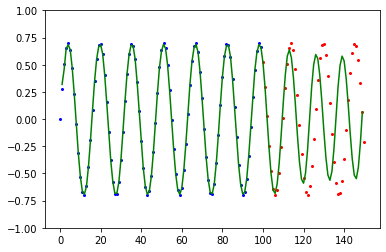

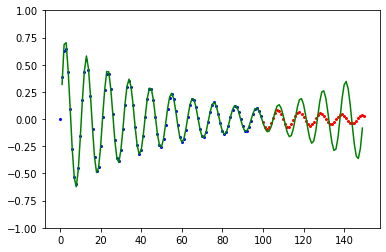

286400 8.485978321669343e-05 0.17861335409890486


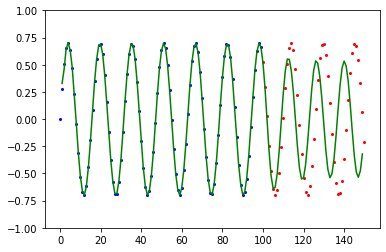

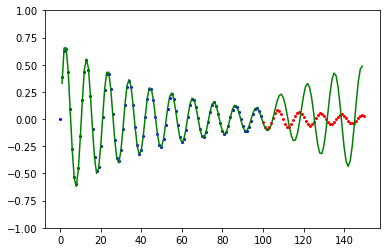

295100 5.635785177169233e-05 0.39993434966153524


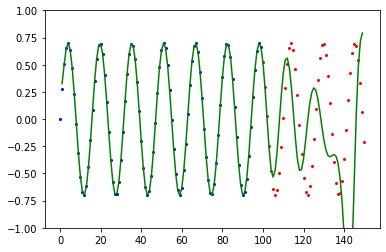

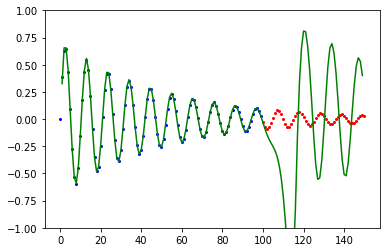

301400 4.626479204594757e-05 0.19835897271728606


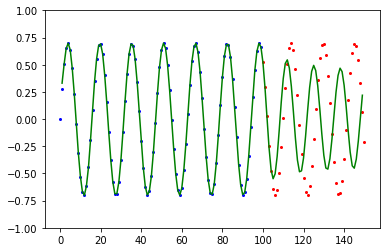

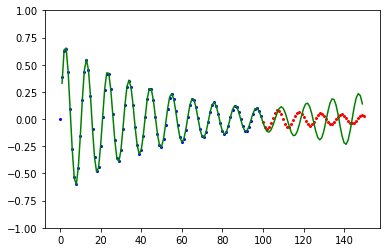

310000 7.752352915263077e-05 0.20389046458638024


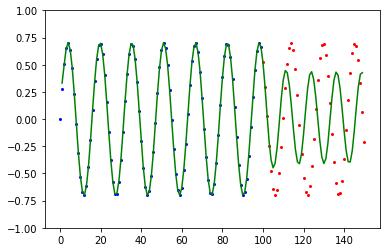

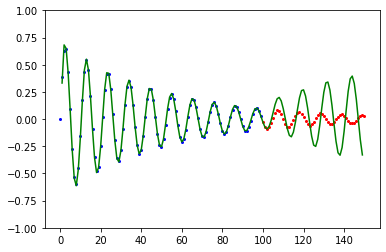

317400 5.274675190331787e-05 0.1255634345900477


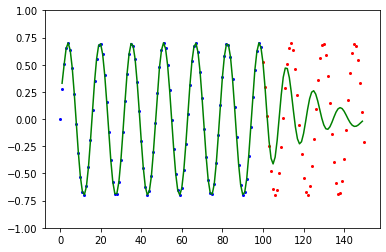

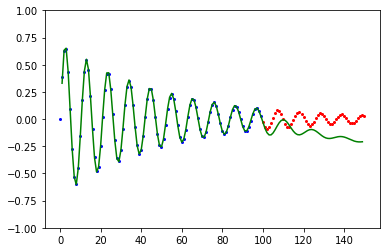

322400 0.0001262711310367335 0.1372230576164992


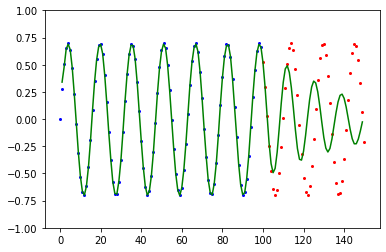

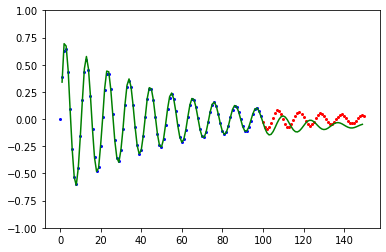

326800 0.0010316114758236682 0.016141860340939538


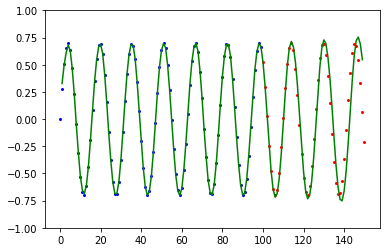

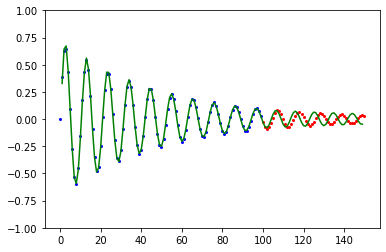

333800 6.518647678759748e-05 0.1828508726015419


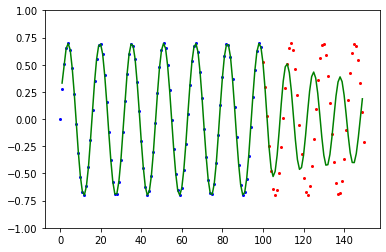

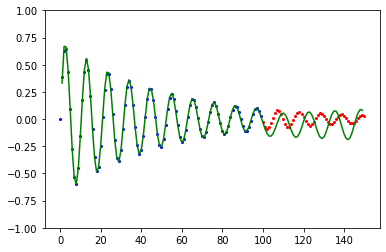

336100 0.09699253167716218 0.12030302744818638


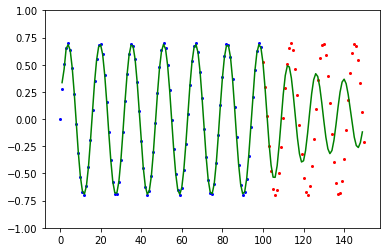

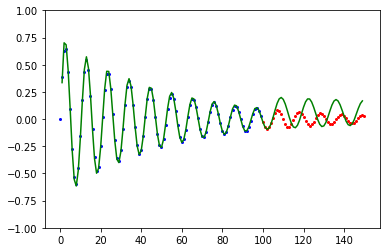

343500 0.00010113777522909143 0.2101070677351284


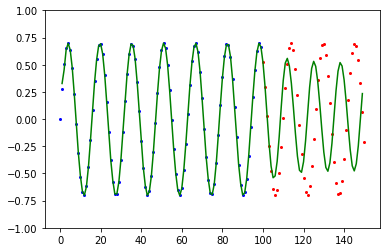

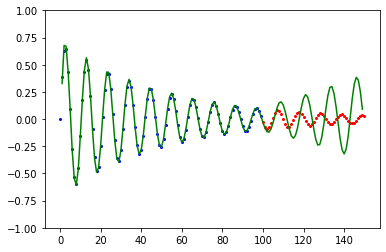

350500 8.038838201499299e-05 0.1853298853511991


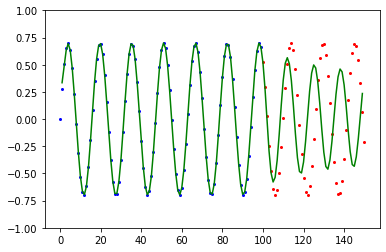

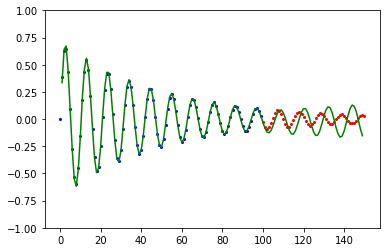

359700 0.00011961718859386834 0.17232253662582273


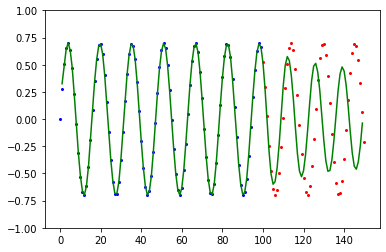

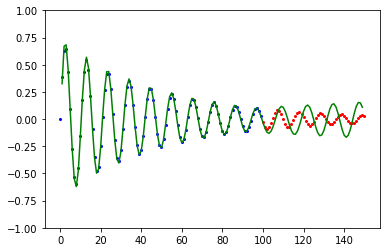

361300 0.010554466872125037 0.15666450377127872


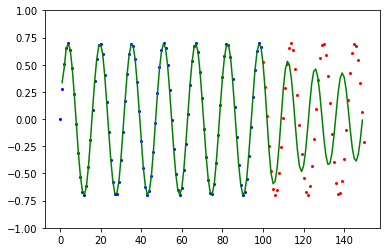

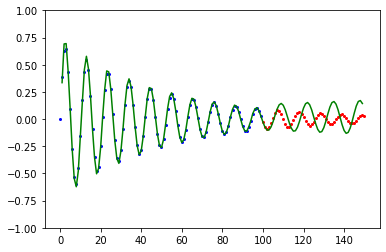

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.14643723, dtype=float64)

In [35]:
len(test_result)

50